# Base 5 — ouro semanal: preparação, STL e Random Forest

Este notebook refaz integralmente a Base 5 para a estrutura atual de
`grupo5_new.csv`. Ele cobre auditoria, preparação semanal, gráficos
exploratórios, STL, força da sazonalidade, ADF/ACF/PACF, Random Forest com
otimização explícita por `for`, avaliação walk-forward, métricas, parâmetros,
tempos, resíduos individuais, ACF residual e Ljung–Box.

**Configuração:** frequência semanal (`W-FRI`), horizonte de uma semana,
split cronológico 75%/25% e `random_state=42`. O alvo e as features temporais
são reconstruídos; `TARGET` e as demais colunas derivadas fornecidas no CSV
ficam apenas na auditoria.


In [ ]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, median_absolute_error, r2_score,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'config' / 'projeto.yaml').is_file():
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from series_temporais.validation.temporal_split import purged_time_series_splits

DATA_PATH = ROOT / 'trabalho/bases/grupo5/grupo5.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = 0.75
TEST_RATIO = 0.25
RANDOM_STATE = 42
REFIT_EVERY = 26
TARGET = 'target_log_return_t_plus_1'
np.random.seed(RANDOM_STATE)


## 1. Ingestão e auditoria do CSV atual

O novo arquivo usa vírgula e contém preço, duas taxas externas, calendário,
lags, janelas e um alvo diário já calculados. A auditoria mede o esquema e a
consistência dessas derivações. Para controlar horizonte e vazamento, somente
`DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a nova
preparação semanal.


In [2]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
primitive_columns = ['GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE']
derived_source_columns = [c for c in expected_columns if c not in ['DATE', *primitive_columns]]

df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='coerce')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)

next_row_match = np.isclose(
    df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False
).mean()
lag_1_match = np.isclose(
    df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False
).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash,
    'linhas': len(df),
    'colunas': len(df.columns),
    'primeira_data': df.DATE.min(),
    'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'datas_fora_de_ordem_apos_ordenacao': int((df.DATE.diff().dt.days.dropna() < 0).sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_ao_preco_da_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_ao_shift_da_tabela_atual_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.notna().all() and df.DATE.is_unique
assert df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())


,valor
arquivo,trabalho\bases\grupo5\grupo5_new.csv
sha256,38622fe40a18c3e94b89971488468f762353ed4234234e...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
datas_fora_de_ordem_apos_ordenacao,0
valores_nulos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 2. Limpeza e preparação semanal

Cada sexta-feira representa o encerramento da semana. Em semanas com dados,
usa-se a última observação disponível. As 254 semanas sem linha de origem
recebem somente o último estado já conhecido (`ffill`), sem consultar o
futuro. Indicadores de cobertura registram esse carregamento. O alvo é o
retorno logarítmico entre o preço conhecido em `t` e o da semana seguinte.


In [3]:
daily = df.set_index('DATE')[primitive_columns].copy()
weekly = daily.resample(WEEKLY_RULE).last()
weekly['source_observations'] = daily.GOLD_PRICE.resample(WEEKLY_RULE).count()
quote_dates = pd.Series(daily.index, index=daily.index).resample(WEEKLY_RULE).max()
weekly['last_quote_date'] = quote_dates
weekly['price_was_carried'] = weekly.GOLD_PRICE.isna().astype(int)

weekly[primitive_columns] = weekly[primitive_columns].ffill()
weekly['last_quote_date'] = weekly.last_quote_date.ffill()
weekly = weekly.reset_index()
weekly = weekly.rename(columns={
    'GOLD_PRICE': 'price_t',
    'TREASURY_10Y': 'treasury_10y_t',
    'FED_FUNDS_RATE': 'fed_funds_rate_t',
})
weekly['quote_age_days'] = (weekly.DATE - weekly.last_quote_date).dt.days
weekly['weeks_without_observation'] = (weekly.quote_age_days // 7).astype(int)
weekly['log_price_t'] = np.log(weekly.price_t)
weekly['log_return_t'] = weekly.log_price_t.diff()

weekly_quality = pd.Series({
    'semanas': len(weekly),
    'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(),
    'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.is_unique and weekly.DATE.is_monotonic_increasing
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
assert weekly[['price_t', 'treasury_10y_t', 'fed_funds_rate_t']].notna().all().all()
display(weekly_quality)
display(weekly.head())


,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,weeks_without_observation,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,0,0,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,0,1,0,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,0,0,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,0,0,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,0,1,0,3.731699,0.000000


## 3. Gráficos exploratórios

Os gráficos mostram o preço, o retorno logarítmico, as taxas externas e a
cobertura semanal. Valores extremos não são removidos automaticamente.


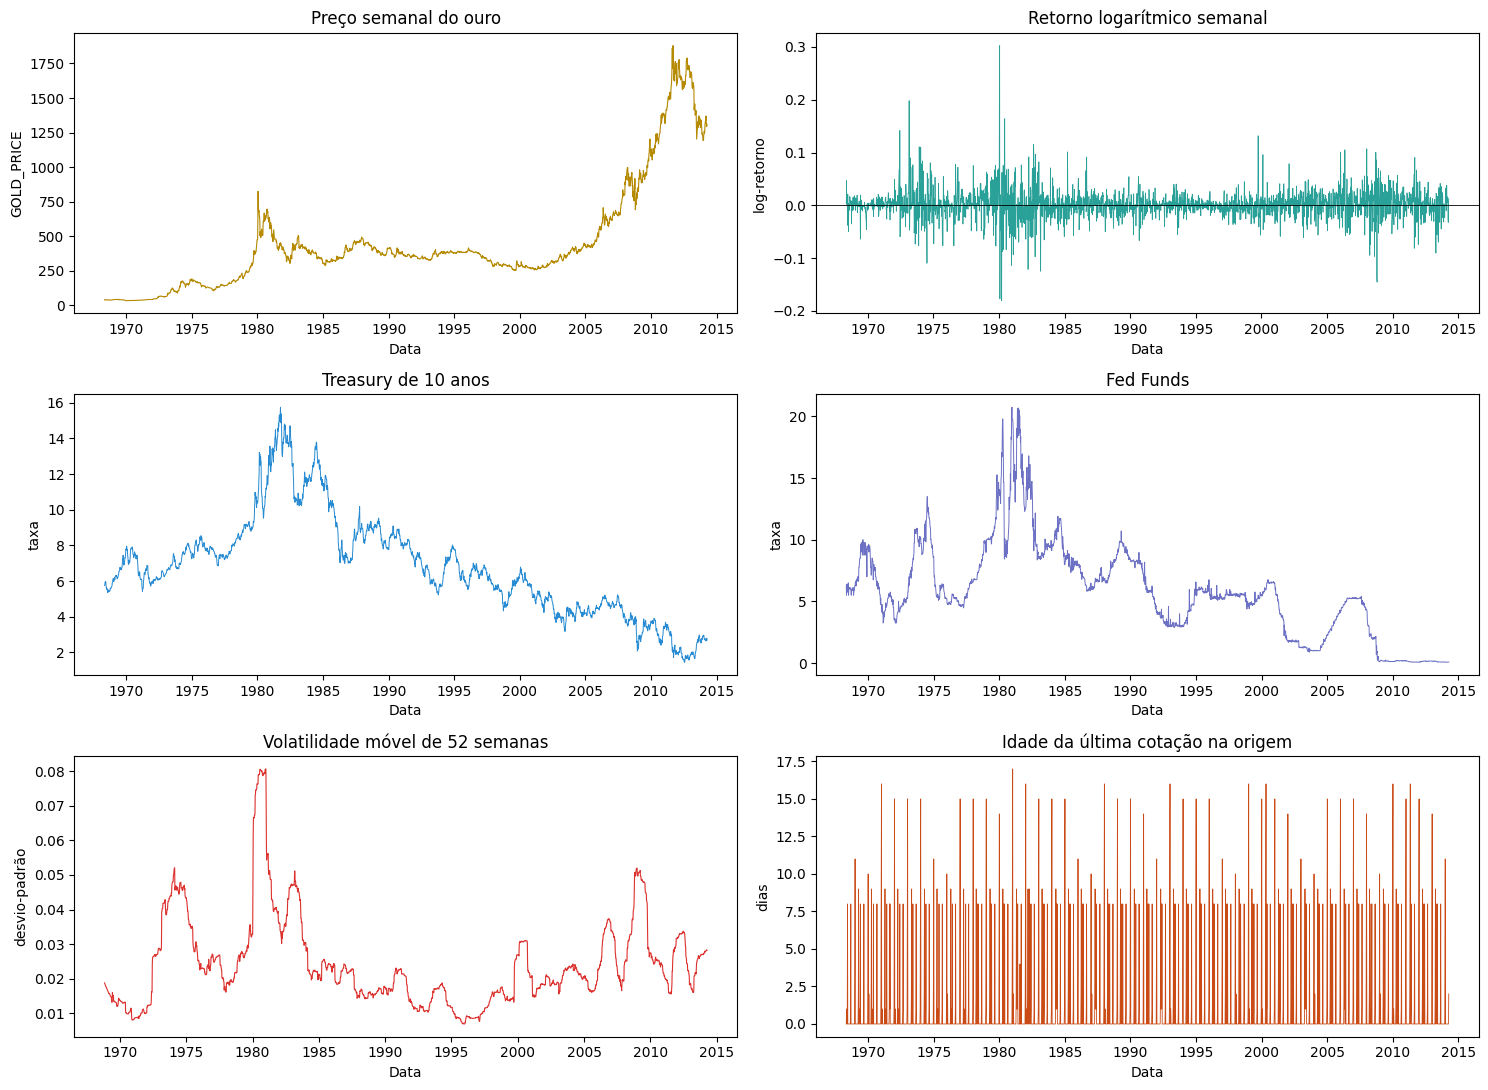

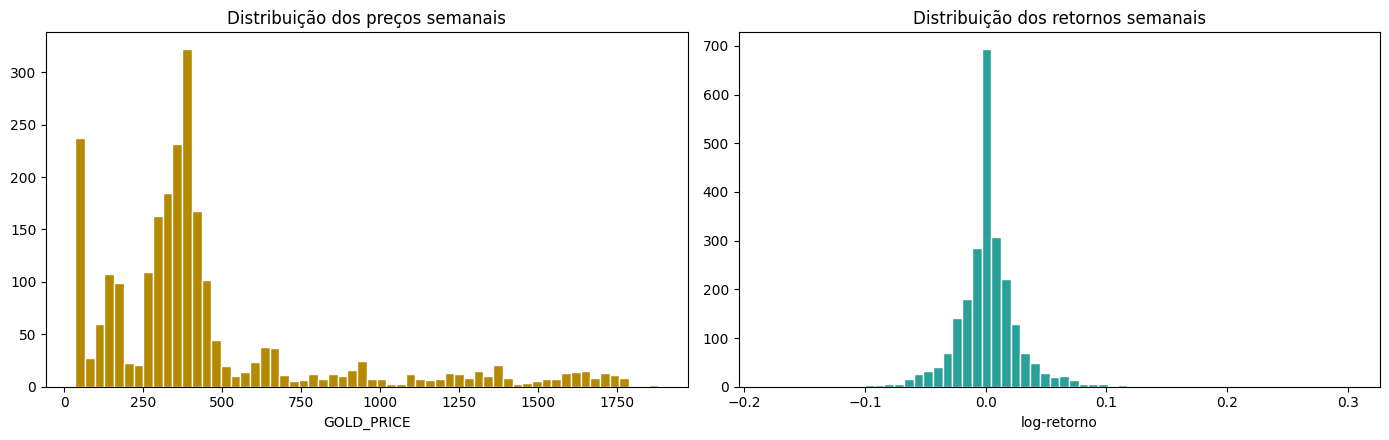

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#2aa198')
axes[0, 1].axhline(0, color='black', lw=.6)
axes[0, 1].set(title='Retorno logarítmico semanal', ylabel='log-retorno')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#268bd2')
axes[1, 0].set(title='Treasury de 10 anos', ylabel='taxa')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds', ylabel='taxa')
axes[2, 0].plot(
    weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(),
    lw=.8, color='#dc322f',
)
axes[2, 0].set(title='Volatilidade móvel de 52 semanas', ylabel='desvio-padrão')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cb4b16')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat:
    ax.set_xlabel('Data')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços semanais', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#2aa198')
axes[1].set(title='Distribuição dos retornos semanais', xlabel='log-retorno')
plt.tight_layout(); plt.show()


## 4. STL e força da sazonalidade

A STL usa o preço semanal regular e período 52. A força sazonal é

\[
F_S = \max\left(0, 1 -
\frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right).
\]

Também calculamos a força da tendência pela fórmula análoga. A decomposição é
diagnóstica e não entra diretamente nas features.


,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendencia,0.979394,52


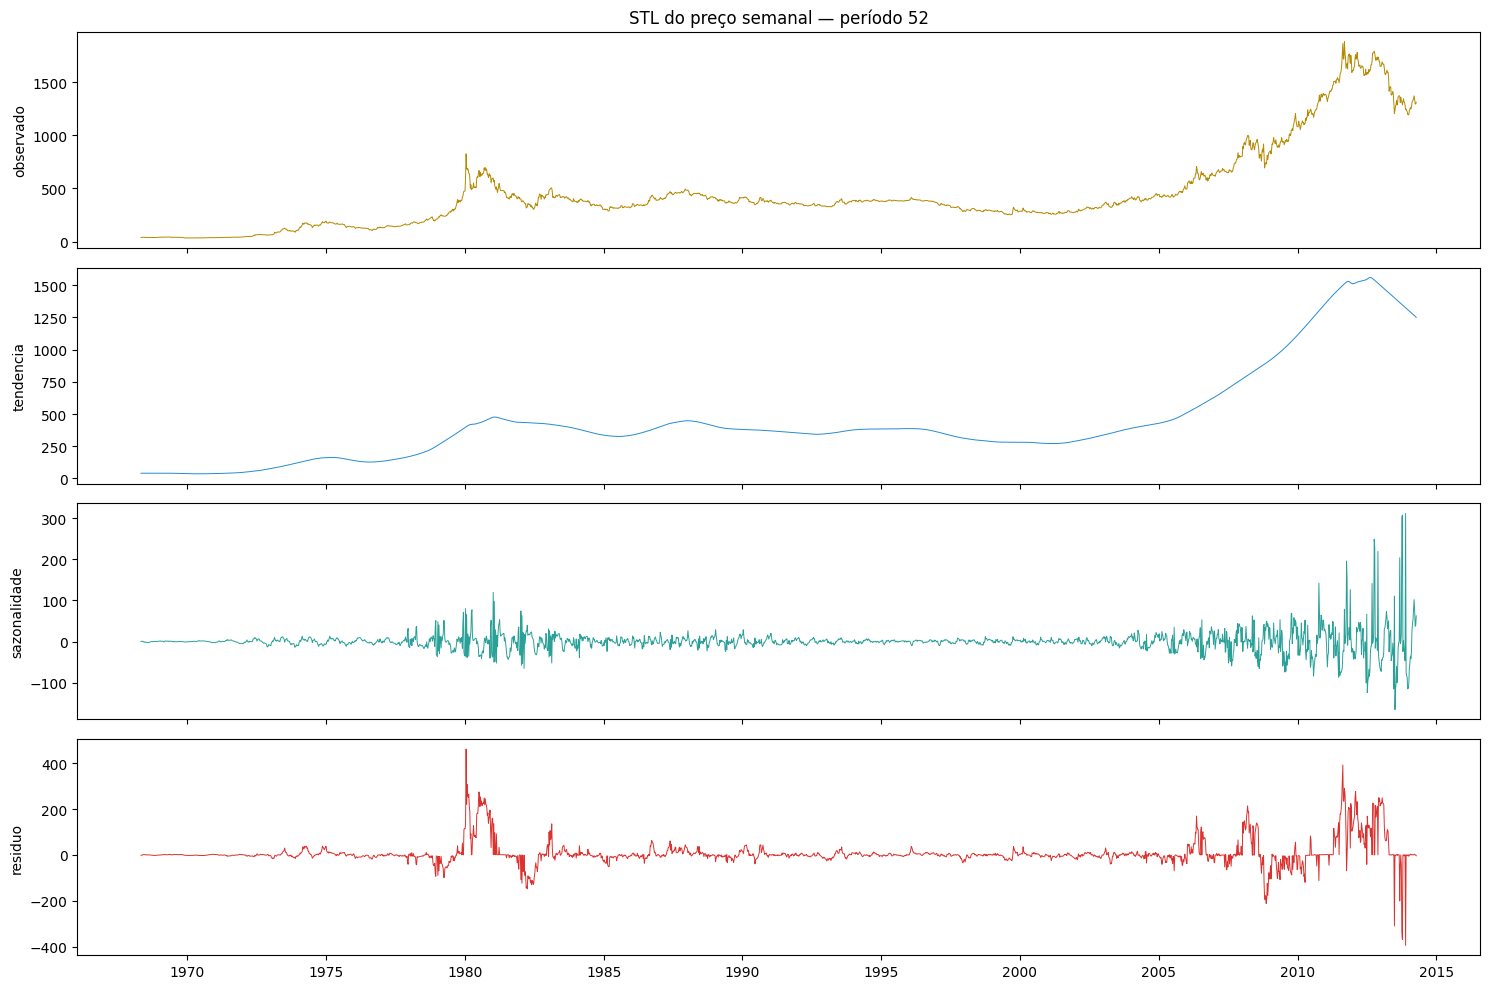

In [5]:
stl_series = weekly.set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
stl_components = pd.DataFrame({
    'observado': stl_result.observed,
    'tendencia': stl_result.trend,
    'sazonalidade': stl_result.seasonal,
    'residuo': stl_result.resid,
}, index=stl_series.index)

residual_variance = np.var(stl_result.resid, ddof=1)
seasonal_denominator = np.var(stl_result.seasonal + stl_result.resid, ddof=1)
trend_denominator = np.var(stl_result.trend + stl_result.resid, ddof=1)
seasonal_strength = max(0.0, 1.0 - residual_variance / seasonal_denominator)
trend_strength = max(0.0, 1.0 - residual_variance / trend_denominator)
strength_report = pd.DataFrame({
    'componente': ['sazonalidade', 'tendencia'],
    'forca': [seasonal_strength, trend_strength],
    'periodo_stl': [STL_PERIOD, STL_PERIOD],
})
display(strength_report)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
for ax, column, color in zip(
    axes, stl_components.columns, ['#b58900', '#268bd2', '#2aa198', '#dc322f']
):
    ax.plot(stl_components.index, stl_components[column], lw=.7, color=color)
    ax.set_ylabel(column)
axes[0].set_title('STL do preço semanal — período 52')
plt.tight_layout(); plt.show()


## 5. Features, corte temporal, ADF, ACF e PACF

Lags e janelas usam apenas o passado. Os níveis de juros da origem e suas
variações até a origem são permitidos; colunas fornecidas `TARGET`, lags e
janelas diárias não entram no modelo. O corte é criado antes dos diagnósticos,
que usam somente treino.


,recorte,linhas,inicio_origem,fim_origem
0,treino,1757,1969-05-09,2003-01-03
1,teste,586,2003-01-17,2014-04-04


,serie,estatistica,p_valor,lags
0,log do preço semanal — treino,-2.511253,1.127602e-01,8
1,retorno log semanal — treino,-14.203771,1.769288e-26,7


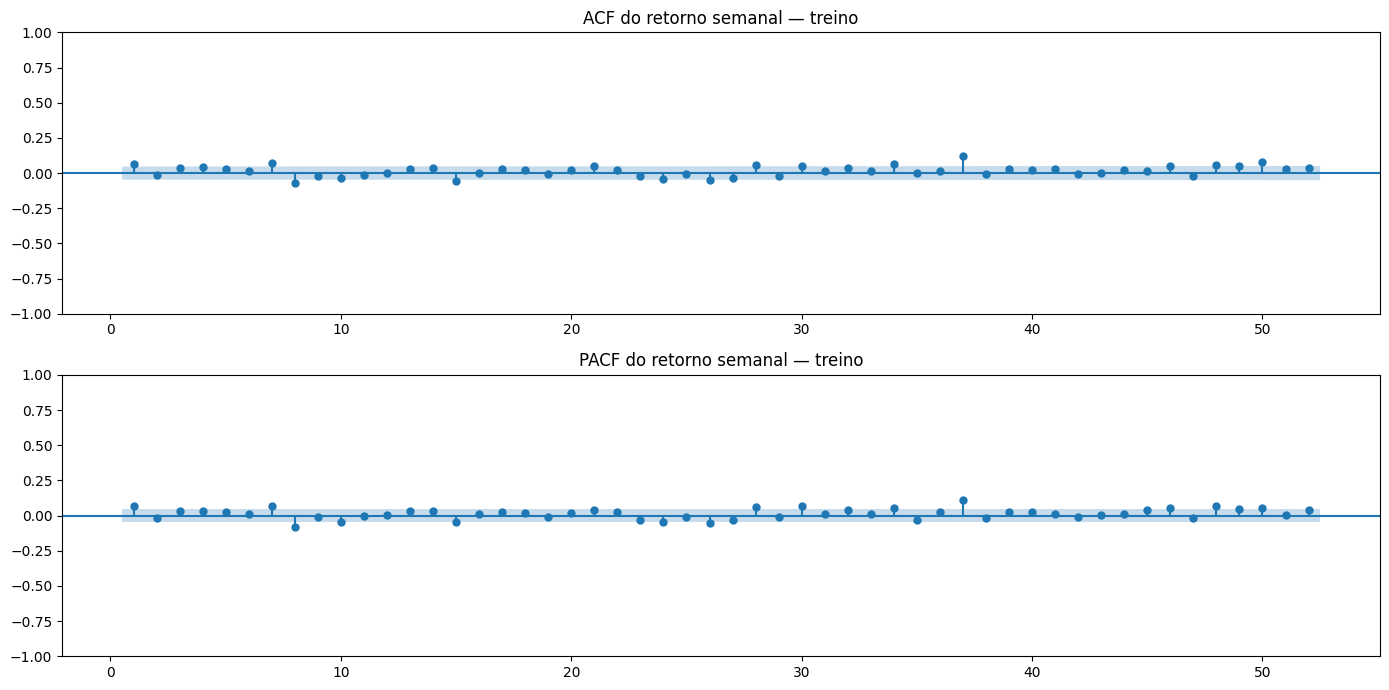

In [6]:
prepared = weekly.copy()
prepared['treasury_change_t'] = prepared.treasury_10y_t.diff()
prepared['fed_funds_change_t'] = prepared.fed_funds_rate_t.diff()

for lag in (1, 2, 4, 8, 13, 26, 52):
    prepared[f'price_lag_{lag}'] = prepared.price_t.shift(lag)
    prepared[f'return_lag_{lag}'] = prepared.log_return_t.shift(lag)
for lag in (1, 4, 13):
    prepared[f'treasury_lag_{lag}'] = prepared.treasury_10y_t.shift(lag)
    prepared[f'fed_funds_lag_{lag}'] = prepared.fed_funds_rate_t.shift(lag)
for window in (4, 13, 26, 52):
    price_history = prepared.price_t.shift(1).rolling(window)
    return_history = prepared.log_return_t.shift(1).rolling(window)
    prepared[f'price_mean_{window}'] = price_history.mean()
    prepared[f'price_std_{window}'] = price_history.std()
    prepared[f'return_vol_{window}'] = return_history.std()

prepared['week_of_year'] = prepared.DATE.dt.isocalendar().week.astype(int)
prepared['month'] = prepared.DATE.dt.month
prepared['week_sin'] = np.sin(2 * np.pi * prepared.week_of_year / 52)
prepared['week_cos'] = np.cos(2 * np.pi * prepared.week_of_year / 52)
prepared['month_sin'] = np.sin(2 * np.pi * prepared.month / 12)
prepared['month_cos'] = np.cos(2 * np.pi * prepared.month / 12)
prepared['target_date'] = prepared.DATE.shift(-1)
prepared['target_price_t_plus_1'] = prepared.price_t.shift(-1)
prepared[TARGET] = prepared.log_price_t.shift(-1) - prepared.log_price_t

excluded = {
    'DATE', 'last_quote_date', 'target_date', 'target_price_t_plus_1', TARGET,
}
feature_columns = [c for c in prepared.columns if c not in excluded]
model_df = (
    prepared.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[*feature_columns, 'target_date', 'target_price_t_plus_1', TARGET])
    .reset_index(drop=True)
)

split_index = int(len(model_df) * TRAIN_RATIO)
first_test_origin = model_df.iloc[split_index].DATE
train_df = model_df.iloc[:split_index].copy()
train_df = train_df.loc[train_df.target_date < first_test_origin].reset_index(drop=True)
test_df = model_df.iloc[split_index:].reset_index(drop=True)
X_train, y_train = train_df[feature_columns], train_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]

assert train_df.target_date.max() < test_df.DATE.min()
assert model_df.target_date.gt(model_df.DATE).all()
assert not set(derived_source_columns).intersection(feature_columns)

def adf_row(name, series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'serie': name, 'estatistica': result[0], 'p_valor': result[1], 'lags': result[2]}

adf_results = pd.DataFrame([
    adf_row('log do preço semanal — treino', train_df.log_price_t),
    adf_row('retorno log semanal — treino', train_df.log_return_t),
])
display(pd.DataFrame({
    'recorte': ['treino', 'teste'],
    'linhas': [len(train_df), len(test_df)],
    'inicio_origem': [train_df.DATE.min(), test_df.DATE.min()],
    'fim_origem': [train_df.DATE.max(), test_df.DATE.max()],
}))
display(adf_results)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_df.log_return_t, lags=52, zero=False, ax=axes[0])
plot_pacf(train_df.log_return_t, lags=52, zero=False, method='ywm', ax=axes[1])
axes[0].set_title('ACF do retorno semanal — treino')
axes[1].set_title('PACF do retorno semanal — treino')
plt.tight_layout(); plt.show()


## 6. Otimização do Random Forest com `for`

O `for` explícito testa 24 combinações em três dobras temporais expansivas
com purga. O teste final não participa da escolha. Os parâmetros escolhidos
ficam fixos durante todo o walk-forward.


In [7]:
parameter_grid = {
    'n_estimators': [100, 250],
    'max_depth': [6, 12, None],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.7],
}
combinations = [
    dict(zip(parameter_grid, values))
    for values in product(*(parameter_grid[name] for name in parameter_grid))
]
cv_splits = list(purged_time_series_splits(
    train_df.DATE, train_df.target_date, n_splits=3
))
search_rows = []
search_start = time.perf_counter()

for combination_id, params in enumerate(combinations, start=1):
    fold_maes = []
    fold_times = []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        candidate = RandomForestRegressor(
            **params, random_state=RANDOM_STATE, n_jobs=-1
        )
        fold_start = time.perf_counter()
        candidate.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        validation_prediction = candidate.predict(X_train.iloc[validation_idx])
        fold_times.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(
            y_train.iloc[validation_idx], validation_prediction
        ))
    search_rows.append({
        'combination_id': combination_id,
        **params,
        'mean_validation_mae': np.mean(fold_maes),
        'std_validation_mae': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_times),
    })

search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae', 'std_validation_mae', 'combination_id']
).reset_index(drop=True)
best_params = {
    key: search_results.iloc[0][key]
    for key in parameter_grid
}
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
if pd.notna(best_params['max_depth']):
    best_params['max_depth'] = int(best_params['max_depth'])
else:
    best_params['max_depth'] = None
display(search_results.head(10))
print('Melhores parâmetros:', best_params)
print(f'Tempo total da busca: {search_seconds:.3f} s')


,combination_id,n_estimators,max_depth,min_samples_leaf,max_features,mean_validation_mae,std_validation_mae,fit_seconds
0,15,250,6.0,3,sqrt,0.017647,0.009915,4.429731
1,3,100,6.0,3,sqrt,0.017662,0.009825,1.329266
2,19,250,12.0,3,sqrt,0.018276,0.009971,3.249845
3,7,100,12.0,3,sqrt,0.018294,0.009545,2.003581
4,16,250,6.0,3,0.7,0.018421,0.010515,5.468586
5,1,100,6.0,1,sqrt,0.018494,0.011244,1.632892
6,4,100,6.0,3,0.7,0.018500,0.010486,2.026239
7,23,250,NaN,3,sqrt,0.018547,0.009661,3.954127
8,13,250,6.0,1,sqrt,0.018552,0.011174,3.474386
9,11,100,NaN,3,sqrt,0.018675,0.009367,1.552286


Melhores parâmetros: {'n_estimators': 250, 'max_depth': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Tempo total da busca: 101.434 s


## 7. Random Forest e avaliação walk-forward

O teste é percorrido em blocos de 26 semanas. Cada reajuste usa somente alvos
conhecidos antes da origem do bloco. Todas as previsões são fora da amostra.


In [8]:
walk_forward_predictions = []
fit_log = []
evaluation_start = time.perf_counter()

for block_start in range(0, len(test_df), REFIT_EVERY):
    block_end = min(block_start + REFIT_EVERY, len(test_df))
    current_origin = test_df.iloc[block_start].DATE
    known_test = test_df.target_date < current_origin
    X_history = pd.concat([X_train, X_test.loc[known_test]], ignore_index=True)
    y_history = pd.concat([y_train, y_test.loc[known_test]], ignore_index=True)

    model = RandomForestRegressor(
        **best_params, random_state=RANDOM_STATE, n_jobs=-1
    )
    fit_start = time.perf_counter()
    model.fit(X_history, y_history)
    block_prediction = model.predict(X_test.iloc[block_start:block_end])
    fit_seconds = time.perf_counter() - fit_start
    walk_forward_predictions.extend(block_prediction)
    fit_log.append({
        'origem_refit': current_origin,
        'linhas_treino': len(X_history),
        'inicio_bloco': block_start,
        'fim_bloco_exclusivo': block_end,
        'fit_seconds': fit_seconds,
    })

evaluation_seconds = time.perf_counter() - evaluation_start
predictions = test_df[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1', TARGET,
]].copy()
predictions = predictions.rename(columns={TARGET: 'y_true'})
predictions['y_pred_random_forest'] = np.asarray(walk_forward_predictions)
predictions['y_pred_retorno_zero'] = 0.0
predictions['residuo_random_forest'] = (
    predictions.y_true - predictions.y_pred_random_forest
)
predictions['erro_absoluto_random_forest'] = predictions.residuo_random_forest.abs()
predictions['erro_quadratico_random_forest'] = predictions.residuo_random_forest.pow(2)
predictions['preco_previsto_rf'] = (
    predictions.price_t * np.exp(predictions.y_pred_random_forest)
)
predictions['preco_previsto_persistencia'] = predictions.price_t
fit_log = pd.DataFrame(fit_log)
assert len(predictions) == len(test_df)
display(predictions.head())


,DATE,target_date,price_t,target_price_t_plus_1,y_true,y_pred_random_forest,y_pred_retorno_zero,residuo_random_forest,erro_absoluto_random_forest,erro_quadratico_random_forest,preco_previsto_rf,preco_previsto_persistencia
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,0.001560,0.0,0.014777,0.014777,0.000218,358.759251,358.20
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,0.001796,0.0,0.015224,0.015224,0.000232,364.754473,364.10
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,0.001617,0.0,-0.001077,0.001077,0.000001,370.949372,370.35
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,0.000988,0.0,-0.040343,0.040343,0.001628,370.916141,370.55
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,0.000830,0.0,-0.007166,0.007166,0.000051,356.545873,356.25


## 8. MAE e demais métricas

MAE, RMSE e MedAE são calculados no retorno semanal. Também são apresentados
R², acurácia direcional e MAE do preço reconstruído. O baseline prevê retorno
zero, equivalente à persistência do último preço conhecido.


In [9]:
def metric_row(name, prediction, predicted_price):
    actual = predictions.y_true.to_numpy()
    prediction = np.asarray(prediction)
    return {
        'modelo': name,
        'MAE_retorno': mean_absolute_error(actual, prediction),
        'RMSE_retorno': mean_squared_error(actual, prediction) ** .5,
        'MedAE_retorno': median_absolute_error(actual, prediction),
        'R2_retorno': r2_score(actual, prediction),
        'acuracia_direcional': np.mean(np.sign(actual) == np.sign(prediction)),
        'MAE_preco': mean_absolute_error(
            predictions.target_price_t_plus_1, predicted_price
        ),
    }

metrics = pd.DataFrame([
    metric_row(
        'Random Forest', predictions.y_pred_random_forest,
        predictions.preco_previsto_rf,
    ),
    metric_row(
        'Baseline retorno zero', predictions.y_pred_retorno_zero,
        predictions.preco_previsto_persistencia,
    ),
])
display(metrics)


,modelo,MAE_retorno,RMSE_retorno,MedAE_retorno,R2_retorno,acuracia_direcional,MAE_preco
0,Random Forest,0.021467,0.029660,0.016777,-0.094699,0.462457,20.035629
1,Baseline retorno zero,0.020101,0.028434,0.016044,-0.006091,0.109215,18.951962


## 9. Registro de parâmetros, versões e tempo

O registro inclui hash da base, configuração, features, hiperparâmetros,
versões, duração da busca, duração do walk-forward e cada reajuste.


In [10]:
experiment_record = pd.DataFrame([{
    'base': 'Base 5 — ouro',
    'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash,
    'frequencia': WEEKLY_RULE,
    'alvo': TARGET,
    'horizonte': '1 semana',
    'split_treino': TRAIN_RATIO,
    'split_teste': TEST_RATIO,
    'random_state': RANDOM_STATE,
    'linhas_treino': len(train_df),
    'linhas_teste': len(test_df),
    'origem_teste_inicial': test_df.DATE.min(),
    'origem_teste_final': test_df.DATE.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'combinacoes_avaliadas': len(combinations),
    'dobras_validacao': len(cv_splits),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds,
    'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log),
    'python': platform.python_version(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit_learn': sklearn.__version__,
    'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)


,0
base,Base 5 — ouro
arquivo,trabalho\bases\grupo5\grupo5_new.csv
sha256,38622fe40a18c3e94b89971488468f762353ed4234234e...
frequencia,W-FRI
alvo,target_log_return_t_plus_1
horizonte,1 semana
split_treino,0.75
split_teste,0.25
random_state,42
linhas_treino,1757


,origem_refit,linhas_treino,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2003-01-17,1757,0,26,1.268179
1,2003-07-18,1782,26,52,1.075703
2,2004-01-16,1808,52,78,1.366408
3,2004-07-16,1834,78,104,1.307007
4,2005-01-14,1860,104,130,1.310065
5,2005-07-15,1886,130,156,1.269856
6,2006-01-13,1912,156,182,1.256323
7,2006-07-14,1938,182,208,1.186932
8,2007-01-12,1964,208,234,1.378230
9,2007-07-13,1990,234,260,1.292495


## 10. Resíduos individuais e diagnóstico gráfico

`predictions` contém uma linha por origem do teste com valor real, previsão,
resíduo e erros individuais.


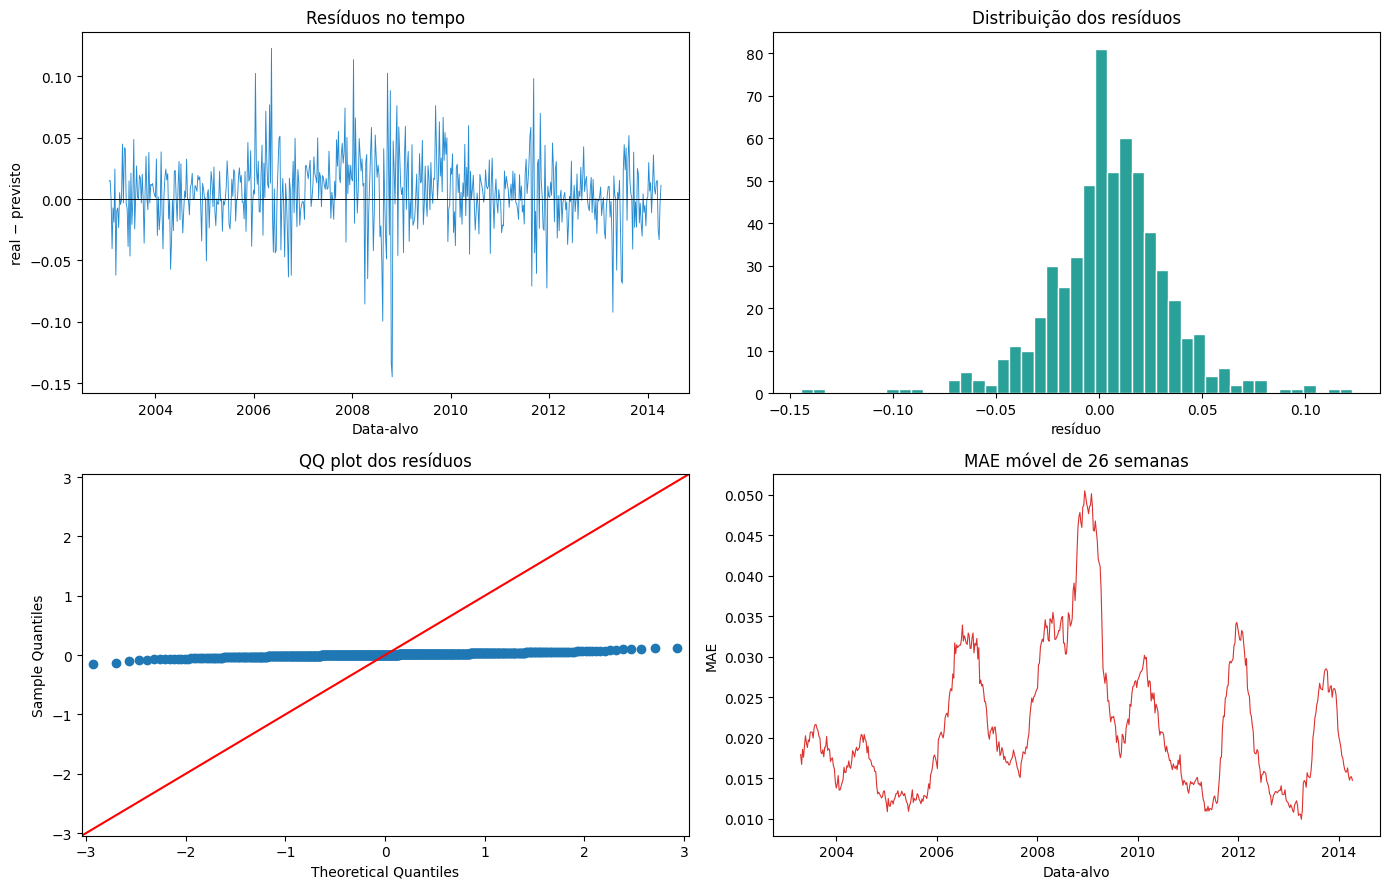

,DATE,target_date,price_t,target_price_t_plus_1,y_true,y_pred_random_forest,y_pred_retorno_zero,residuo_random_forest,erro_absoluto_random_forest,erro_quadratico_random_forest,preco_previsto_rf,preco_previsto_persistencia
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,0.001560,0.0,0.014777,0.014777,0.000218,358.759251,358.20
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,0.001796,0.0,0.015224,0.015224,0.000232,364.754473,364.10
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,0.001617,0.0,-0.001077,0.001077,0.000001,370.949372,370.35
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,0.000988,0.0,-0.040343,0.040343,0.001628,370.916141,370.55
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,0.000830,0.0,-0.007166,0.007166,0.000051,356.545873,356.25
...,...,...,...,...,...,...,...,...,...,...,...,...
581,2014-03-07,2014-03-14,1348.25,1370.00,0.016003,0.000786,0.0,0.015217,0.015217,0.000232,1349.310252,1348.25
582,2014-03-14,2014-03-21,1370.00,1338.50,-0.023261,0.001483,0.0,-0.024745,0.024745,0.000612,1372.033692,1370.00
583,2014-03-21,2014-03-28,1338.50,1295.75,-0.032460,0.000609,0.0,-0.033069,0.033069,0.001094,1339.315464,1338.50
584,2014-03-28,2014-04-04,1295.75,1293.50,-0.001738,0.001181,0.0,-0.002919,0.002919,0.000009,1297.280794,1295.75


In [11]:
residuals = predictions.residuo_random_forest
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(predictions.target_date, residuals, lw=.65, color='#268bd2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos no tempo', xlabel='Data-alvo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=45, edgecolor='white', color='#2aa198')
axes[0, 1].set(title='Distribuição dos resíduos', xlabel='resíduo')
sm.qqplot(residuals, line='45', ax=axes[1, 0])
axes[1, 0].set_title('QQ plot dos resíduos')
axes[1, 1].plot(
    predictions.target_date,
    predictions.erro_absoluto_random_forest.rolling(26, min_periods=13).mean(),
    lw=.8, color='#dc322f',
)
axes[1, 1].set(title='MAE móvel de 26 semanas', xlabel='Data-alvo', ylabel='MAE')
plt.tight_layout(); plt.show()
display(predictions)


## 11. ACF dos resíduos e Ljung–Box

A ACF mostra a dependência residual por defasagem. O Ljung–Box testa a
hipótese conjunta de ausência de autocorrelação nos lags 1, 4, 13 e 26.


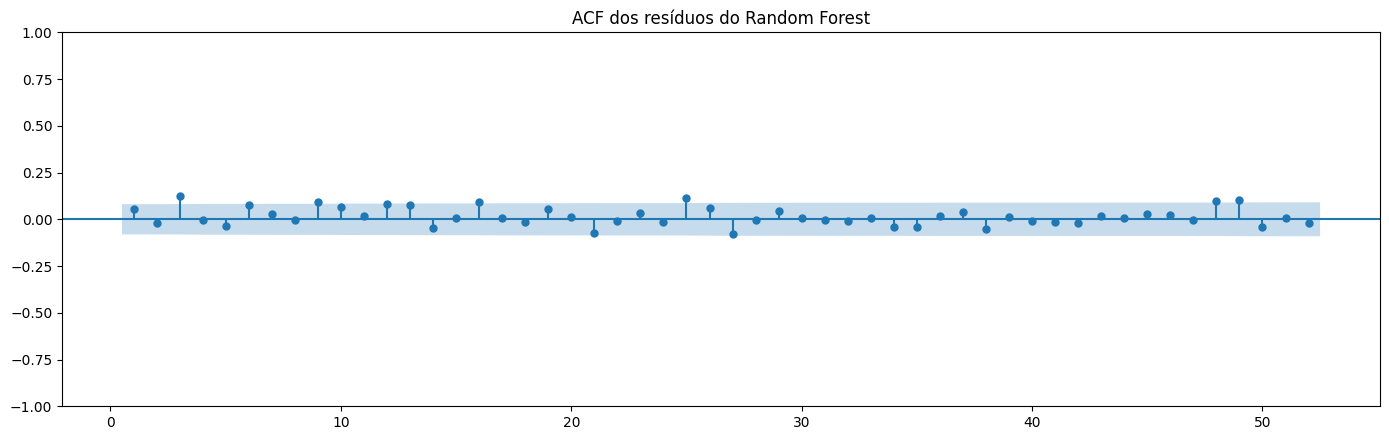

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,1.626592,0.202175,False
4,11.177009,0.024645,True
13,31.150591,0.003205,True
26,54.648778,0.000840,True


In [12]:
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=52, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do Random Forest')
plt.tight_layout(); plt.show()

ljung_box = acorr_ljungbox(residuals, lags=[1, 4, 13, 26], return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)


## 12. Síntese da execução

- CSV atual: 9.864 linhas, 16 colunas e SHA-256 iniciado em `38622fe4`.
- Série: 2.398 semanas regulares; 254 sem linha de origem.
- STL: força sazonal `0,0000` e força de tendência `0,9794`.
- ADF: log-preço não estacionário a 5%; retorno semanal estacionário.
- Modelo: 49 features, 1.757 linhas de treino e 586 previsões de teste.
- Melhor RF: 250 árvores, profundidade 6, folha mínima 3 e `sqrt`.
- MAE RF: `0,021467`; MAE da persistência: `0,020101`.
- O RF não superou a persistência nesta execução.
- Ljung–Box: não rejeita ruído branco no lag 1; rejeita nos lags 4, 13 e 26.

Os tempos medidos foram 101,43 s na busca e 27,95 s no walk-forward; podem
variar entre computadores. As tabelas acima preservam todas as previsões,
resíduos e configurações associadas ao hash atual.
